# Build Chloropleth Maps Using ZIP3 data from *All of Us* Participants
---

## ZIP3 Participant Proportion vs. 2020 Census Population
---
- Calculates, for each ZIP3, the proportion of the local population (2020 Census) that are enrolled *All of Us* participants.
- Pulls ZIP3 codes for *All of Us* participants from the CDR and merges with `zip3_population_density_2014_2023.csv` (see notes on this file below).
- Produces `dataset_zip3.prop_percent.csv`, used by the maps below.

### Note on `zip3_population_density_2014_2023.csv`

This file is a **precomputed, static input** — it is uploaded directly to
this workspace rather than generated or downloaded at runtime, since the
underlying source data (historical ACS estimates, 2020 ZCTA boundaries) is
fixed and will not change. Recomputing it on every notebook run would add
unnecessary compute cost with no benefit.

**How this file was created (last recalculated February 18, 2026, to
account for population changes between 2014–2023):**

1. **ZCTA land area** — Square-mile areas for each ZIP5 were obtained from
   2020 TIGER/Line ZCTA shapefiles. 2020 ZCTA boundaries were applied to all
   years for consistency; minor boundary changes since 2010 are not expected
   to affect ZIP5 or ZIP3 level results.

2. **Population estimates** — Total population per ZCTA for each year
   2014–2023 was queried from the U.S. Census Bureau's American Community
   Survey (ACS) 5-year estimates via the ACS API (`B01003_001E`).

3. **Merge and aggregation** — Computed population density per ZIP5 per year.
   ZIP3 was extracted from ZIP5, and population and area were summed across all
   constituent ZIP5s within each ZIP3 before computing ZIP3-level population density,
   producing the file `zip3_population_density_2014_2023.csv`  
   **Header: year, zip3, population, area_sq_miles, population_density**
---

In [44]:
# ══════════════════════════════════════════════════════════════════════════
# This script pulls ZIP3 codes for All of Us participants from the CDR,
# then merges in ZIP3-level population data (2020 Census/ACS-derived) to
# calculate what proportion of each ZIP3's population is enrolled in
# All of Us.
#
# Output: dataset_zip3.prop_percent.csv
#   columns: zip3, n_individuals, population, prop_percent
#
# See markdown cell above for information on origin of zip3_population_density_2014_2023.csv
# ══════════════════════════════════════════════════════════════════════════

import os
import pandas as pd
import pandas_gbq
from google.cloud import bigquery

client = bigquery.Client()
WORKSPACE_CDR = "wb-silky-artichoke-2408.C2025Q4R6"  # V9
POP_DENSITY_FILE = "zip3_population_density_2014_2023.csv"
OUTPUT_FILE = "dataset_zip3.prop_percent.csv"
POP_YEAR = 2020

# ── ZIP3 exclusion list ──────────────────────────────────────────────────
# Excludes territories, military, federal offices, and PO-box-only ZIP3s
# with no meaningful population data.
# To restrict to contiguous US only, also add:
#   Alaska: '995','996','997','998','999'
#   Hawaii: '967','968'
#   Puerto Rico: '006','007','009'
EXCLUDE_ZIP3 = {
    '969', '008',                                                       # US Virgin Islands, Guam
    '090','091','092','093','094','095','096','097','098','099','569',  # Military
    '202','203','204','205',                                            # Federal offices
    '753','772',                                                        # PO Box ZIP3s, no population data
    '000',                                                              # Missing ZIP3
}

# ── 1. FETCH ZIP3 DATA FROM ALL OF US CDR ────────────────────────────────
# observation_concept_id 3043579 = ZIP code tabulation area (OMOP)
observation_sql = f"""
    SELECT
        observation.person_id,
        observation.value_as_number,
        observation.value_as_string
    FROM
        (SELECT *
         FROM `{WORKSPACE_CDR}.observation` observation
         WHERE observation_concept_id IN (3043579)
        ) observation
"""

dataset_df = pandas_gbq.read_gbq(
    observation_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook",
)
print(f"Raw data shape: {dataset_df.shape}")

# ── 2. EXTRACT AND CLEAN ZIP3 ────────────────────────────────────────────
df = dataset_df.copy()
df["zip3"] = df["value_as_string"].str.extract(r"^(\d{3})")  # anchored to avoid partial matches

df_clean = df[df["zip3"].notna() & ~df["zip3"].isin(EXCLUDE_ZIP3)].copy()
df_clean = df_clean[["person_id", "zip3"]]

n_dropped = len(df) - len(df_clean)
print(f"Dropped {n_dropped} rows (missing/excluded ZIP3); {len(df_clean)} rows remain")

# ── 3. COUNT PARTICIPANTS PER ZIP3 ───────────────────────────────────────
zip3_counts = df_clean.groupby("zip3").size().reset_index(name="n_individuals")

# ── 4. LOAD POPULATION DATA AND MERGE ────────────────────────────────────
pop_df = pd.read_csv(POP_DENSITY_FILE)
pop_df["zip3"] = pop_df["zip3"].astype(str).str.zfill(3)
pop_year_df = pop_df[pop_df["year"] == POP_YEAR][["zip3", "population"]]
zip3_counts = zip3_counts.merge(pop_year_df, on="zip3", how="left")

# ── 5. COMPUTE PROPORTION AND SAVE ───────────────────────────────────────
zip3_counts["prop_percent"] = (zip3_counts["n_individuals"] / zip3_counts["population"]) * 100
zip3_counts.to_csv(OUTPUT_FILE, index=False)

Downloading:   0%|          |

Raw data shape: (746980, 3)
Dropped 32203 rows (missing/excluded ZIP3); 714777 rows remain
  zip3  n_individuals  population  prop_percent
0  006            788     1064354      0.074036
1  007           2045     1217832      0.167921
2  009           2977      971244      0.306514
3  010            644      475217      0.135517
4  011            123      169408      0.072606
Saved: dataset_zip3.prop_percent.csv


---
# Wildfire Smoke Exposure Bubble Map, by ZIP3 (2020)
---
- Plots wildfire smoke exposure (% of days with smoke plumes) by ZIP3 as bubbles sized by *All of Us* participant proportion.
- Requires `dataset_zip3.prop_percent.csv` (from the ZIP3 participant-proportion cell above) and `zip3_year_light_med_heavy_2014_2025.csv` (see file origin note below).

### Note on `zip3_year_light_med_heavy_2014_2025.csv`

This file is a **precomputed, static input** — it is uploaded directly to
this workspace rather than generated or downloaded at runtime. Producing it
required SLURM-based batch processing of daily NOAA smoke plume data via
the `amadeus` R package, which is not feasible to re-run inside the
notebook itself.

**How this file was created:**

1. **Download smoke plume data** — Daily smoke plume data (NOAA satellite–
   derived, accessed via the `amadeus` R package) were downloaded for all
   dates from 2014–2025. The total number of days per month was calculated
   for each ZIP5, using `geometry = st_union(geometry)` to associate smoke
   plume polygons with ZIP5 boundaries.

2. **Aggregate ZIP5 → ZIP3** — Aggregated ZIP5 records sharing a ZIP3
   prefix.

3. **2020 ZCTA boundaries were used for all years in the ZIP5→lat/long
   conversion step** - This is expected to have negligible effect on ZIP3-level
   results (ZIP5-level results would require year-specific ZIP boundaries,
   since those change more between years).

4. **Aggregate monthly → yearly ZIP3 totals** — Converted monthly ZIP3 smoke
   totals into yearly totals by summing light, medium, and heavy day counts
   separately across all months in a year. This produces, for each ZIP3 and year,
   the total number of light, medium, and heavy smoke days observed that year.
   This produced file `zip3_year_light_med_heavy_2014_2025.csv`  
    **Header: zip3, year, light, medium, heavy**
---

Downloaded zip3_shapes.geojson (1895830 bytes)
After dissolve: 887 rows for 887 unique ZIP3s
CONUS ZIP3s plotted: 861


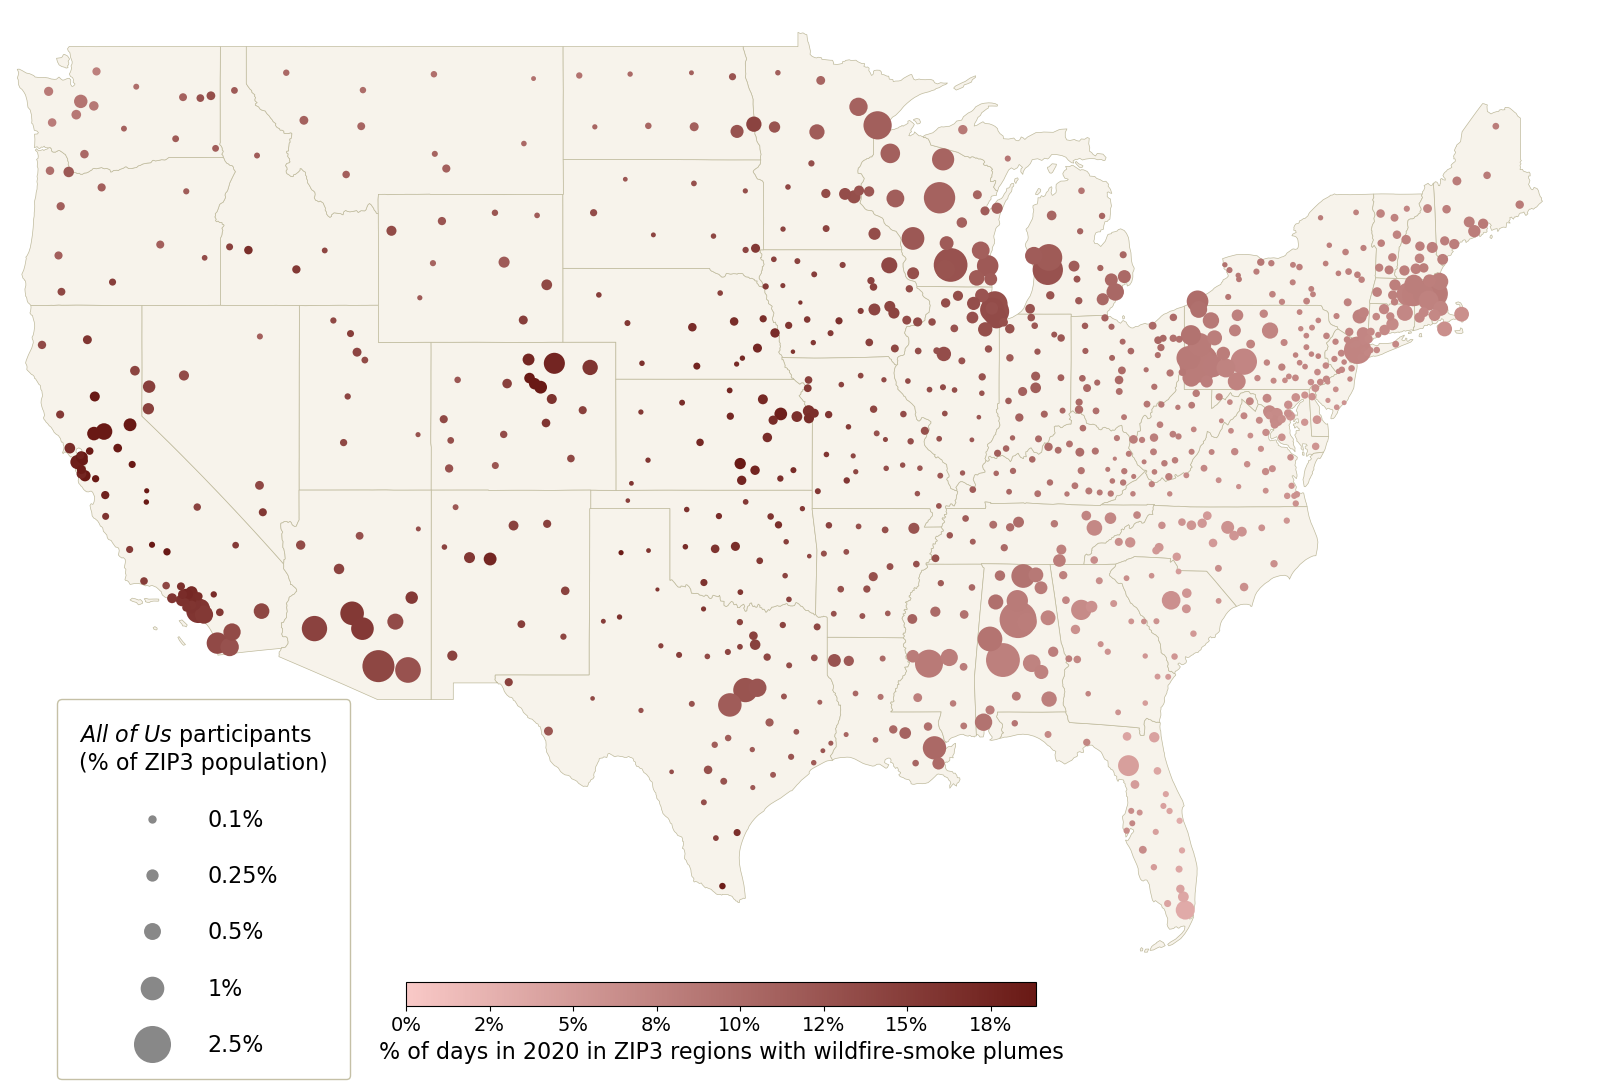

Saved: smoke_bubble_map_2020.png


In [46]:
# ══════════════════════════════════════════════════════════════════════════
# Bubble map: wildfire smoke exposure (% of days with smoke plumes) by ZIP3,
# with bubble size showing the proportion of each ZIP3's population that
# are All of Us participants.
#
# Prerequisites:
#   - dataset_zip3.prop_percent.csv (from the ZIP3 participant-proportion
#     cell earlier in this notebook)
#   - zip3_year_light_med_heavy_2014_2025.csv (see markdown note above on
#     how this file was created)
# ══════════════════════════════════════════════════════════════════════════

import os
os.environ["CPL_LOG"] = "/dev/null"       # suppress GDAL's C-level stderr logging
os.environ["PROJ_DATA"] = "/opt/conda/envs/jupyter/share/proj"
os.environ["PROJ_LIB"] = "/opt/conda/envs/jupyter/share/proj"
import warnings
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings("ignore")

YEAR = 2020      # can change to display different wildfire-smoke
DAYS_YEAR = 365  # change to 366 for leap years: 2016, 2020, 2024

STATES_DIR = "us_states_shp"
STATES_PATH = f"{STATES_DIR}/cb_2020_us_state_20m.shp"
STATES_URL = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_20m.zip"

SMOKE_FILE = "zip3_year_light_med_heavy_2014_2025.csv"
PARTICIPANTS_FILE = "dataset_zip3.prop_percent.csv"
OUTPUT_FILE = f"smoke_bubble_map_{YEAR}.png"

# Pinned to a specific commit for reproducibility (file has been static
# since this commit; see ZIP3 GeoJSON provenance note)
ZIP3_URL = "https://raw.githubusercontent.com/mathbiol/sparcs/b962671ea4717cf9e2387ecf3c8a15597b4f79d8/zip3.geojson"
ZIP3_PATH = "zip3_shapes.geojson"

EXCLUDE_ZIP3 = {
    # US Virgin Islands, Guam
    '969', '008',
    # Military
    '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '569',
    # Federal offices
    '202', '203', '204', '205',
    # PO Box ZIP3 codes that have no population data
    '753', '772',
    # Drop individuals without zip3 information
    '000',
}

# ── 1. US STATES SHAPEFILE ────────────────────────────────────────────────
if not os.path.exists(STATES_PATH):
    urllib.request.urlretrieve(STATES_URL, "us_states.zip")
    with zipfile.ZipFile("us_states.zip") as z:
        z.extractall(STATES_DIR)

states = gpd.read_file(STATES_PATH)
conus = states[~states["STUSPS"].isin(["AK", "HI", "PR", "VI", "GU", "MP", "AS"])]

# ── 2. SMOKE DATA ─────────────────────────────────────────────────────────
smoke = pd.read_csv(SMOKE_FILE)
smoke.columns = smoke.columns.str.strip()
smoke["zip3"] = smoke["zip3"].astype(str).str.strip().str.zfill(3)
smoke = smoke[smoke["year"] == YEAR].copy()
smoke["smoke_pct"] = (smoke["light"] + smoke["medium"] + smoke["heavy"]) / DAYS_YEAR * 100

# ── 3. PARTICIPANT PROPORTIONS ────────────────────────────────────────────
participants_df = pd.read_csv(PARTICIPANTS_FILE, dtype={"zip3": str})
participants_df["zip3"] = participants_df["zip3"].str.zfill(3)
participants_df = participants_df[["zip3", "n_individuals", "prop_percent"]]

# ── 4. CENTROIDS FROM GEOJSON ─────────────────────────────────────────────
if os.path.exists(ZIP3_PATH):
    os.remove(ZIP3_PATH)  # force fresh download to avoid stale/mismatched schema

r = requests.get(ZIP3_URL, timeout=30)
r.raise_for_status()
with open(ZIP3_PATH, "wb") as f:
    f.write(r.content)
print(f"Downloaded {ZIP3_PATH} ({len(r.content)} bytes)")

gdf = gpd.read_file(ZIP3_PATH)
gdf = gdf.rename(columns={"ZIP": "zip3"})
gdf["zip3"] = gdf["zip3"].astype(str).str.strip().str.zfill(3)

# Repair invalid geometries before dissolving
gdf["geometry"] = gdf.geometry.buffer(0)

# Collapse duplicate/multi-part rows into one geometry per ZIP3
gdf = gdf.dissolve(by="zip3", as_index=False)
print(f"After dissolve: {len(gdf)} rows for {gdf['zip3'].nunique()} unique ZIP3s")

gdf_proj = gdf.to_crs("ESRI:102003")
gdf["centroid"] = gdf_proj.geometry.representative_point()
gdf["lon"] = gdf.set_geometry("centroid").to_crs("EPSG:4326").geometry.x
gdf["lat"] = gdf.set_geometry("centroid").to_crs("EPSG:4326").geometry.y
centroids = gdf[["zip3", "lon", "lat"]].copy()

# ── 5. MERGE ───────────────────────────────────────────────────────────────
df = smoke.merge(participants_df, on="zip3", how="inner")
df = df.merge(centroids, on="zip3", how="inner")
df = df.rename(columns={"prop_percent": "n_participants"})

# ── 6. RESTRICT TO CONUS ZIP3s ────────────────────────────────────────────
def region(z):
    n = int(z)
    if 995 <= n <= 999: return "AK"
    if 967 <= n <= 968: return "HI"
    if 6 <= n <= 9: return "PR"
    return "CONUS"

df["region"] = df["zip3"].apply(region)
df = df[df["region"] == "CONUS"].copy()
df = df[~df["zip3"].isin(EXCLUDE_ZIP3)].copy()
print(f"CONUS ZIP3s plotted: {len(df)}")

# ── 7. BUBBLE COLOR: smoke % ──────────────────────────────────────────────
CMAP = LinearSegmentedColormap.from_list("custom_red", ["#F9C9C7", "#691915"])
VMIN = 0
VMAX = df["smoke_pct"].quantile(0.98)
norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
df["color"] = df["smoke_pct"].apply(lambda p: "#d1d1d1" if p == 0 else mcolors.to_hex(CMAP(norm(p))))

# ── 8. BUBBLE SIZE: proportion of local population ────────────────────────
max_p = df["n_participants"].max()
MIN_S, MAX_S = 8, 800

def bubble_size(n):
    return MIN_S + (n / max_p) * (MAX_S - MIN_S)

df["size"] = df["n_participants"].apply(bubble_size)

# ── 9. FIGURE ──────────────────────────────────────────────────────────────
BG = "white"
LAND = "#F7F3EB"
BORDER = "#BFBA9C"

fig = plt.figure(figsize=(18, 12), facecolor=BG)
ax = fig.add_axes([0.1, 0.10, 0.88, 0.82])
ax.set_facecolor(BG)
conus.plot(ax=ax, color=LAND, edgecolor=BORDER, linewidth=0.5)

df_plot = df.sort_values("n_participants", ascending=False)
ax.scatter(df_plot["lon"], df_plot["lat"], s=df_plot["size"], c=df_plot["color"],
           edgecolors="none", zorder=3)

ax.set_xlim(-125, -65)
ax.set_ylim(24, 50)
ax.set_aspect(1.4)
ax.set_anchor("W")  # lock map to left side, prevents drift
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

# ── 10. BUBBLE SIZE LEGEND ─────────────────────────────────────────────────
size_vals = [0.1, 0.25, 0.50, 1.0, 2.5]
size_handles = [
    mlines.Line2D([], [], marker="o", color="none",
                  markerfacecolor="#888888", markeredgecolor="none",
                  markersize=np.sqrt(bubble_size(v)),
                  label=f"{v:.2g}%")
    for v in size_vals
]
fig.legend(
    handles=size_handles,
    title="$\\it{All\\ of\\ Us}$ participants\n(% of ZIP3 population)",
    loc="lower left", bbox_to_anchor=(0.12, 0.01), ncol=1, fontsize=16, title_fontsize=16,
    frameon=True, framealpha=0.9, edgecolor="#BFBA9C",
    handletextpad=1.5, labelspacing=1.5, borderpad=1.0,
)

# ── 11. COLORBAR ───────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.32, 0.08, 0.35, 0.02])
cb = ColorbarBase(cbar_ax, cmap=CMAP, norm=norm, orientation="horizontal")
cb.set_label(f"% of days in {YEAR} in ZIP3 regions with wildfire-smoke plumes", fontsize=16)
cb.ax.tick_params(labelsize=14)
cb.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── 12. SAVE ───────────────────────────────────────────────────────────────
plt.savefig(OUTPUT_FILE, dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"Saved: {OUTPUT_FILE}")